#### Using https://earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/raster-data-processing/reproject-raster/

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely.geometry import box
from pathlib import Path
import geopandas as gpd


In [3]:
basin = gpd.read_file("MCS_outline/basin_outline.shp")
basin.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

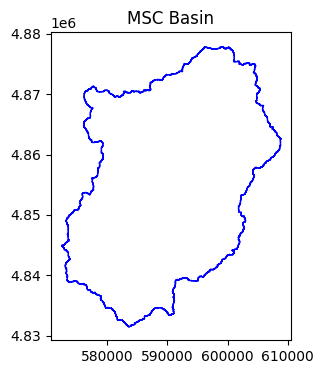

In [170]:
# Plot the clipped data
f, ax = plt.subplots(figsize=(10, 4))

basin.plot(ax=ax,
                       edgecolor="blue",
                       color="white")

ax.set(title="MSC Basin")
plt.show()

In [216]:
buffer_distance = 7000 # Example: 100 units (e.g., meters if in EPSG:3857)
basin_buffered = basin.copy() # Create a copy to avoid modifying original
basin_buffered['geometry'] = basin_buffered['geometry'].buffer(buffer_distance)
basin_buffered.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [219]:
# Suppose you have a polygon (or GeoSeries)
xmin,ymin,xmax,ymax =  basin_buffered.total_bounds
print(xmin,ymin,xmax,ymax)
# convert to polygon
geom =box(*basin_buffered.total_bounds)
x_ext, y_ext = geom.exterior.xy

print(f"Bounds: {xmin}, {ymin}, {xmax}, {ymax}")



565490.0 4824530.0 615770.0 4884940.0
Bounds: 565490.0, 4824530.0, 615770.0, 4884940.0


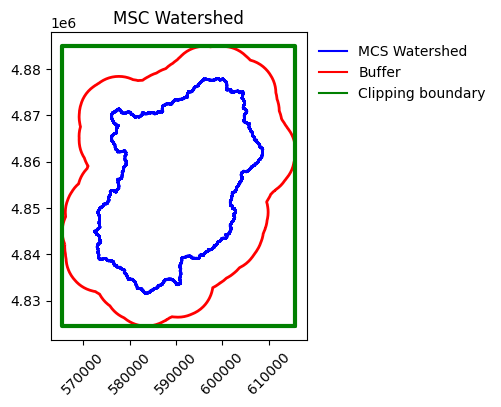

In [173]:

#plot buffer
f, ax = plt.subplots(figsize=(10, 4))

basin.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=2, label="Original Basin")
basin_buffered.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2, label="7 km Buffer")
ax.plot(x_ext, y_ext, color='green', linewidth=3, solid_capstyle='round', zorder=1, label = "Clipping boundary")

blue_line = mlines.Line2D([], [], color='blue', label='MCS Watershed')
red_line = mlines.Line2D([], [], color='red', label='Buffer')
green_line = mlines.Line2D([], [], color='green', label='Clipping boundary')
plt.xticks(rotation=45)

ax.legend(
    handles=[blue_line, red_line, green_line],
    loc='upper left',  # position relative to bbox
    bbox_to_anchor=(1, 1),  # (x, y): 1 means right edge of plot
    frameon=False
)

ax.set_title("MSC Watershed")
plt.show()

In [4]:
home_dir = Path("." / "SIRO")
out_dir = home_dir / "GIS" / "reproject"
out_dir.mkdir(parents=True, exist_ok=True)

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [229]:
##EVT
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "LF2022_EVT_230_CONUS/LF2022_EVT_230_CONUS/Tif/LC22_EVT_230.tif"),
    str(out_dir / "LC22_EVT_230.tif")]

print(" ".join(cmd))

gdalwarp -t_srs EPSG:32611 -te 565490.0 4824530.0 615770.0 4884940.0 -r near -co COMPRESS=LZW -co TILED=YES -co BIGTIFF=YES C:\Users\RDCRLSMC\Desktop\SIRO\LF2022_EVT_230_CONUS\LF2022_EVT_230_CONUS\Tif\LC22_EVT_230.tif C:\Users\RDCRLSMC\Desktop\SIRO\GIS\reproject\LC22_EVT_230.tif


In [230]:
##DEM
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "GIS/merged.tif"),
    str(out_dir / "DEM.tif")]

print(" ".join(cmd))

gdalwarp -t_srs EPSG:32611 -te 565490.0 4824530.0 615770.0 4884940.0 -r near -co COMPRESS=LZW -co TILED=YES -co BIGTIFF=YES C:\Users\RDCRLSMC\Desktop\SIRO\GIS\merged.tif C:\Users\RDCRLSMC\Desktop\SIRO\GIS\reproject\DEM.tif


In [232]:
##FH
cmd = [
    "gdalwarp",
    "-t_srs", "EPSG:32611",
    "-te", str(xmin), str(ymin), str(xmax), str(ymax),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",   # handle large files
    str(home_dir / "GIS/Forest_height_2019_NAM.tif"),
    str(out_dir / "Forest_height_2019_NAM.tif")]

print(" ".join(cmd))

gdalwarp -t_srs EPSG:32611 -te 565490.0 4824530.0 615770.0 4884940.0 -r near -co COMPRESS=LZW -co TILED=YES -co BIGTIFF=YES C:\Users\RDCRLSMC\Desktop\SIRO\GIS\Forest_height_2019_NAM.tif C:\Users\RDCRLSMC\Desktop\SIRO\GIS\reproject\Forest_height_2019_NAM.tif
